In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('mental_health_burnout_tech_2026.csv')
df.head(2)

,employee_id,age,gender,country,job_role,seniority_level,years_experience,years_at_company,company_size,industry,...,autonomy_score,stress_score,burnout_score,phq9_score,phq9_category,gad7_score,gad7_category,burnout_level,seeks_mental_health_support,job_change_intention
0,1,33,Male,India,Software Engineer,Lead,11,6.4,Small (51-200),Healthcare Tech,...,6.1,10.0,10.0,19,Moderately Severe (15-19),12,Moderate (10-14),Severe,1,1
1,2,24,Non-binary,USA,Full Stack Developer,Manager,0,5.7,Startup (1-50),Fintech,...,5.4,9.3,7.0,8,Mild (5-9),6,Mild (5-9),High,1,1


In [5]:
df.shape

(100000, 36)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   employee_id                  100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   country                      100000 non-null  object 
 4   job_role                     100000 non-null  object 
 5   seniority_level              100000 non-null  object 
 6   years_experience             100000 non-null  int64  
 7   years_at_company             100000 non-null  float64
 8   company_size                 100000 non-null  object 
 9   industry                     100000 non-null  object 
 10  work_mode                    100000 non-null  object 
 11  salary_usd                   100000 non-null  int64  
 12  work_hours_per_week          100000 non-null  int64  
 13  

In [7]:
df.describe()

,employee_id,age,years_experience,years_at_company,salary_usd,work_hours_per_week,meetings_per_day,team_size,sleep_hours_per_night,exercise_days_per_week,...,job_satisfaction_score,social_support_score,deadline_pressure_score,autonomy_score,stress_score,burnout_score,phq9_score,gad7_score,seeks_mental_health_support,job_change_intention
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,31.305670,9.343690,2.492581,83285.490230,47.104080,4.162244,18.009650,6.102392,2.968730,...,4.834823,5.383951,6.385095,5.836528,7.055399,5.401675,6.27194,5.118920,0.497890,0.320020
std,28867.657797,6.427924,6.401543,2.450426,39392.584827,5.246902,1.937849,12.607473,0.998808,1.772762,...,1.920796,1.832774,1.769242,1.836491,2.128530,2.668425,4.95427,4.007513,0.499998,0.466486
min,1.000000,22.000000,0.000000,0.100000,40000.000000,35.000000,0.000000,2.000000,3.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,26.000000,4.000000,0.700000,46018.250000,44.000000,2.800000,8.000000,5.400000,2.000000,...,3.500000,4.100000,5.200000,4.600000,5.500000,3.500000,2.00000,2.000000,0.000000,0.000000
50%,50000.500000,31.000000,9.000000,1.700000,76630.500000,47.000000,4.000000,16.000000,6.100000,3.000000,...,4.800000,5.400000,6.400000,5.800000,7.100000,5.400000,6.00000,5.000000,0.000000,0.000000
75%,75000.250000,36.000000,14.000000,3.500000,109113.000000,51.000000,5.400000,25.000000,6.800000,4.000000,...,6.200000,6.600000,7.600000,7.100000,8.900000,7.400000,10.00000,8.000000,1.000000,1.000000
max,100000.000000,55.000000,25.000000,15.000000,267961.000000,72.000000,12.000000,59.000000,10.000000,7.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,27.00000,21.000000,1.000000,1.000000


In [8]:
# Missing Value Check

df.isnull().sum()

employee_id                    0
age                            0
gender                         0
country                        0
job_role                       0
seniority_level                0
years_experience               0
years_at_company               0
company_size                   0
industry                       0
work_mode                      0
salary_usd                     0
work_hours_per_week            0
meetings_per_day               0
team_size                      0
sleep_hours_per_night          0
exercise_days_per_week         0
vacation_days_taken            0
therapy_access                 0
uses_therapy                   0
ai_tools_daily                 0
manager_support_score          0
work_life_balance_score        0
job_satisfaction_score         0
social_support_score           0
deadline_pressure_score        0
autonomy_score                 0
stress_score                   0
burnout_score                  0
phq9_score                     0
phq9_categ

In [9]:
# Check Duplicates

df.duplicated().sum()

np.int64(0)

In [14]:
# Standardize Column Names

df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['employee_id', 'age', 'gender', 'country', 'job_role',
       'seniority_level', 'years_experience', 'years_at_company',
       'company_size', 'industry', 'work_mode', 'salary_usd',
       'work_hours_per_week', 'meetings_per_day', 'team_size',
       'sleep_hours_per_night', 'exercise_days_per_week',
       'vacation_days_taken', 'therapy_access', 'uses_therapy',
       'ai_tools_daily', 'manager_support_score', 'work_life_balance_score',
       'job_satisfaction_score', 'social_support_score',
       'deadline_pressure_score', 'autonomy_score', 'stress_score',
       'burnout_score', 'phq9_score', 'phq9_category', 'gad7_score',
       'gad7_category', 'burnout_level', 'seeks_mental_health_support',
       'job_change_intention'],
      dtype='object')

In [18]:
# Burnout Risk

conditions = [
    df['burnout_score'] < 4,
    (df['burnout_score'] >= 4) & (df['burnout_score'] < 7),
    df['burnout_score'] >= 7
]

labels = ['Low', 'Moderate', 'High']

df['burnout_risk'] = np.select(conditions, labels, default='Unknown')

In [23]:
# Work Intensity

df['work_intensity'] = (
    df['work_hours_per_week'] * 0.7 +
    df['meetings_per_day'] * 0.3
)

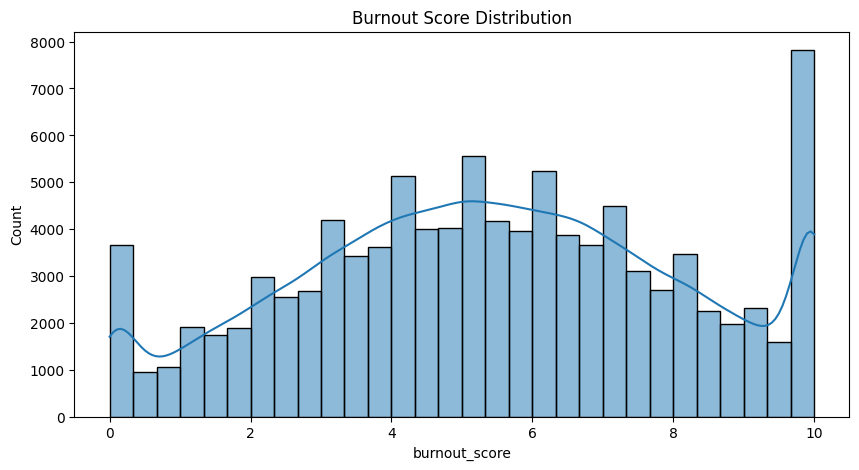

In [28]:
# Burnout Score Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    df['burnout_score'],
    kde=True,
    bins=30
)

plt.title('Burnout Score Distribution')
plt.show()

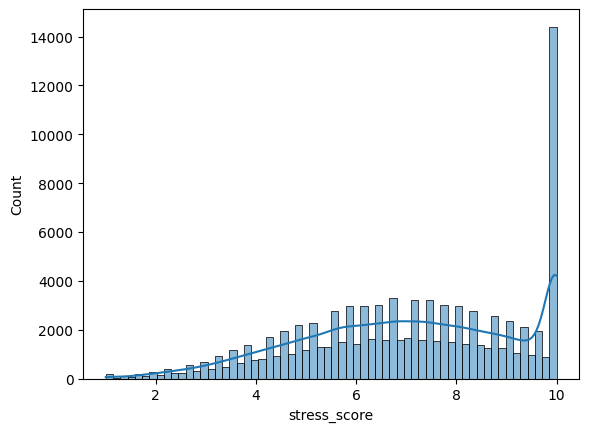

In [29]:
# Stress Score Distribution

sns.histplot(df['stress_score'], kde=True)
plt.show()

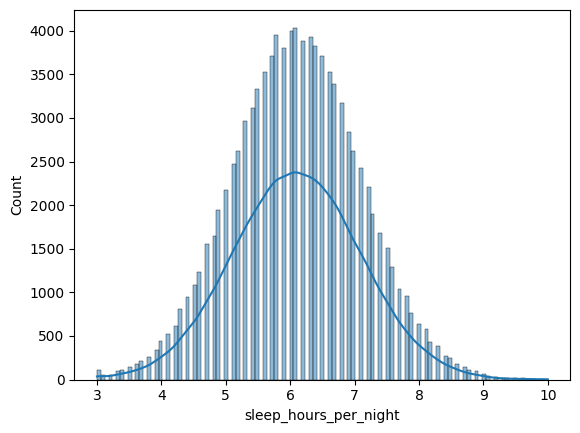

In [30]:
# Sleep Hours Distribution

sns.histplot(df['sleep_hours_per_night'], kde=True)
plt.show()

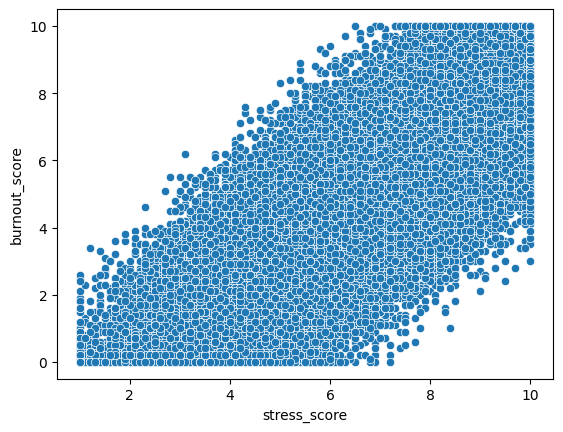

In [25]:
# Stress vs Burnout

sns.scatterplot(
    x='stress_score',
    y='burnout_score',
    data=df
)

plt.show()

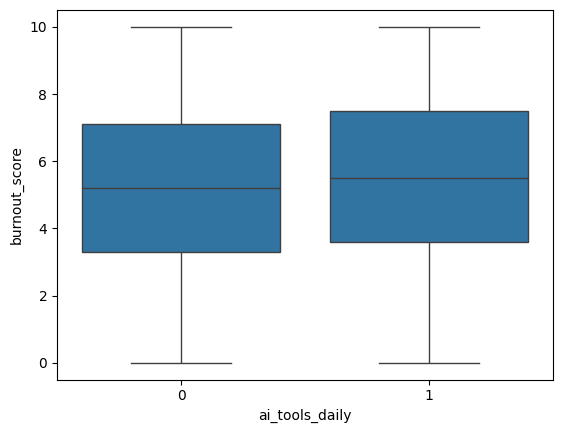

In [26]:
# AI Usage vs Burnout

sns.boxplot(
    x='ai_tools_daily',
    y='burnout_score',
    data=df
)

plt.show()

## CATEGORICAL ANALYSIS

In [32]:
# Work Mode Distribution

df['work_mode'].value_counts()

work_mode
Hybrid     39856
Remote     34936
On-site    25208
Name: count, dtype: int64

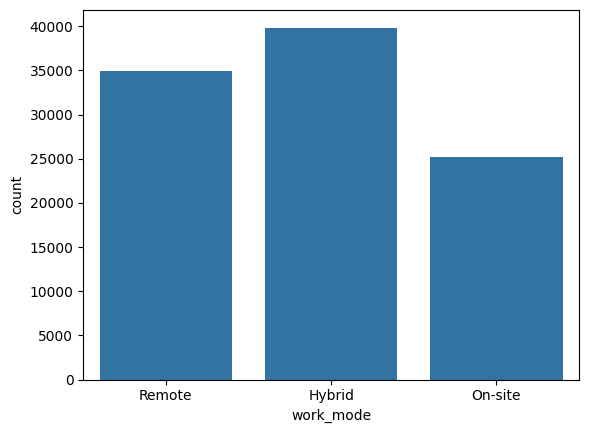

In [33]:
sns.countplot(x='work_mode', data=df)
plt.show()

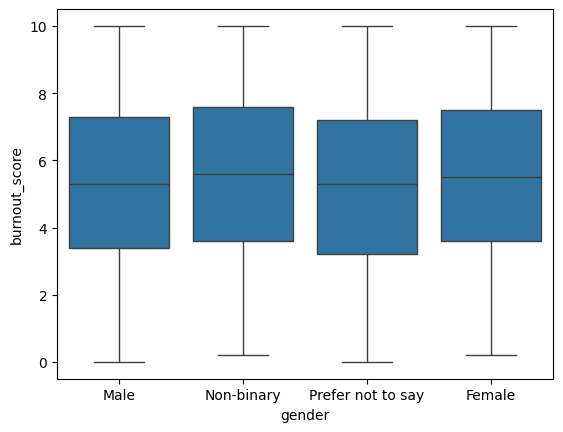

In [34]:
# Burnout by Gender

sns.boxplot(
    x='gender',
    y='burnout_score',
    data=df
)

plt.show()

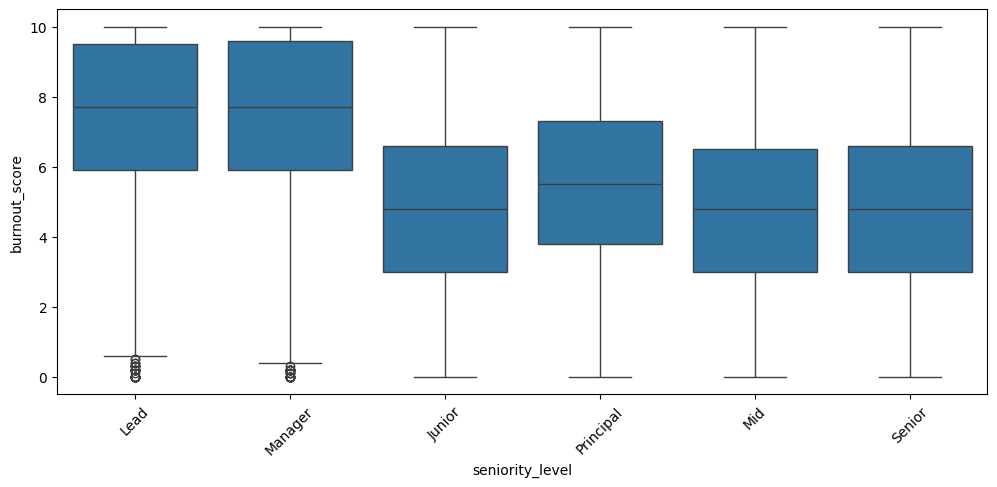

In [35]:
# Burnout by Seniority

plt.figure(figsize=(12,5))

sns.boxplot(
    x='seniority_level',
    y='burnout_score',
    data=df
)

plt.xticks(rotation=45)
plt.show()

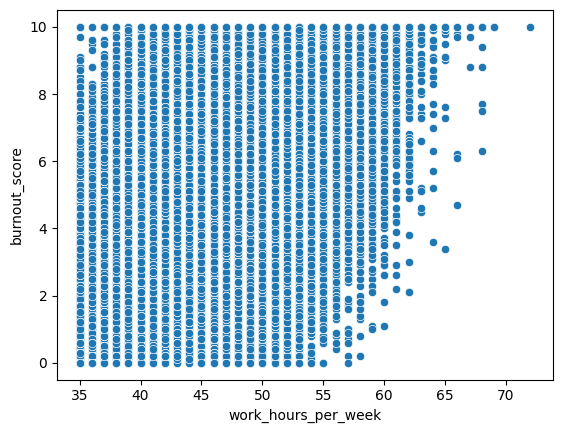

In [36]:
# Work Hours vs Burnout

sns.scatterplot(
    x='work_hours_per_week',
    y='burnout_score',
    data=df
)

plt.show()

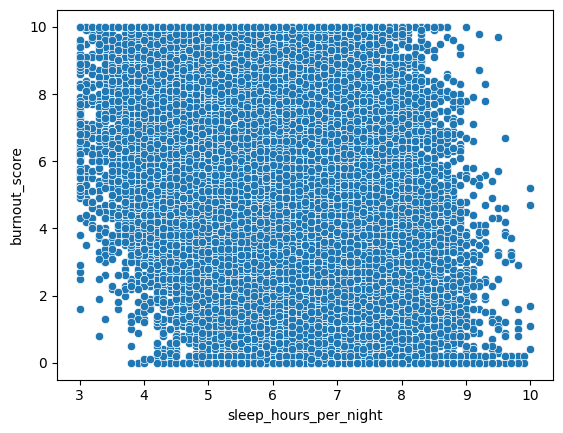

In [37]:
# Sleep vs Burnout

sns.scatterplot(
    x='sleep_hours_per_night',
    y='burnout_score',
    data=df
)

plt.show()

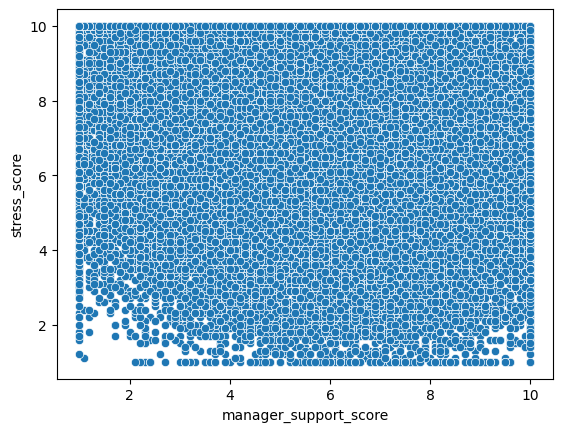

In [38]:
# Manager Support vs Stress

sns.scatterplot(
    x='manager_support_score',
    y='stress_score',
    data=df
)

plt.show()

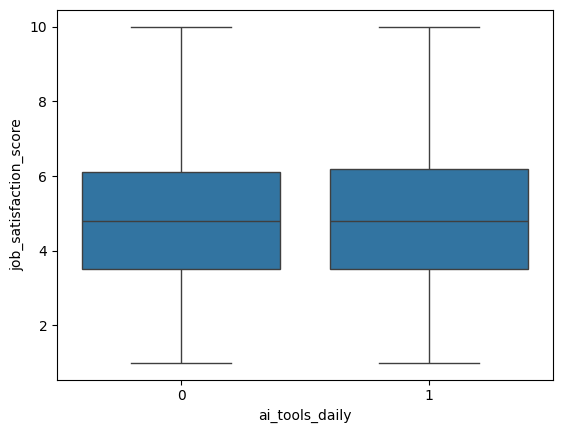

In [39]:
# AI Usage vs Job Satisfaction

sns.boxplot(
    x='ai_tools_daily',
    y='job_satisfaction_score',
    data=df
)

plt.show()

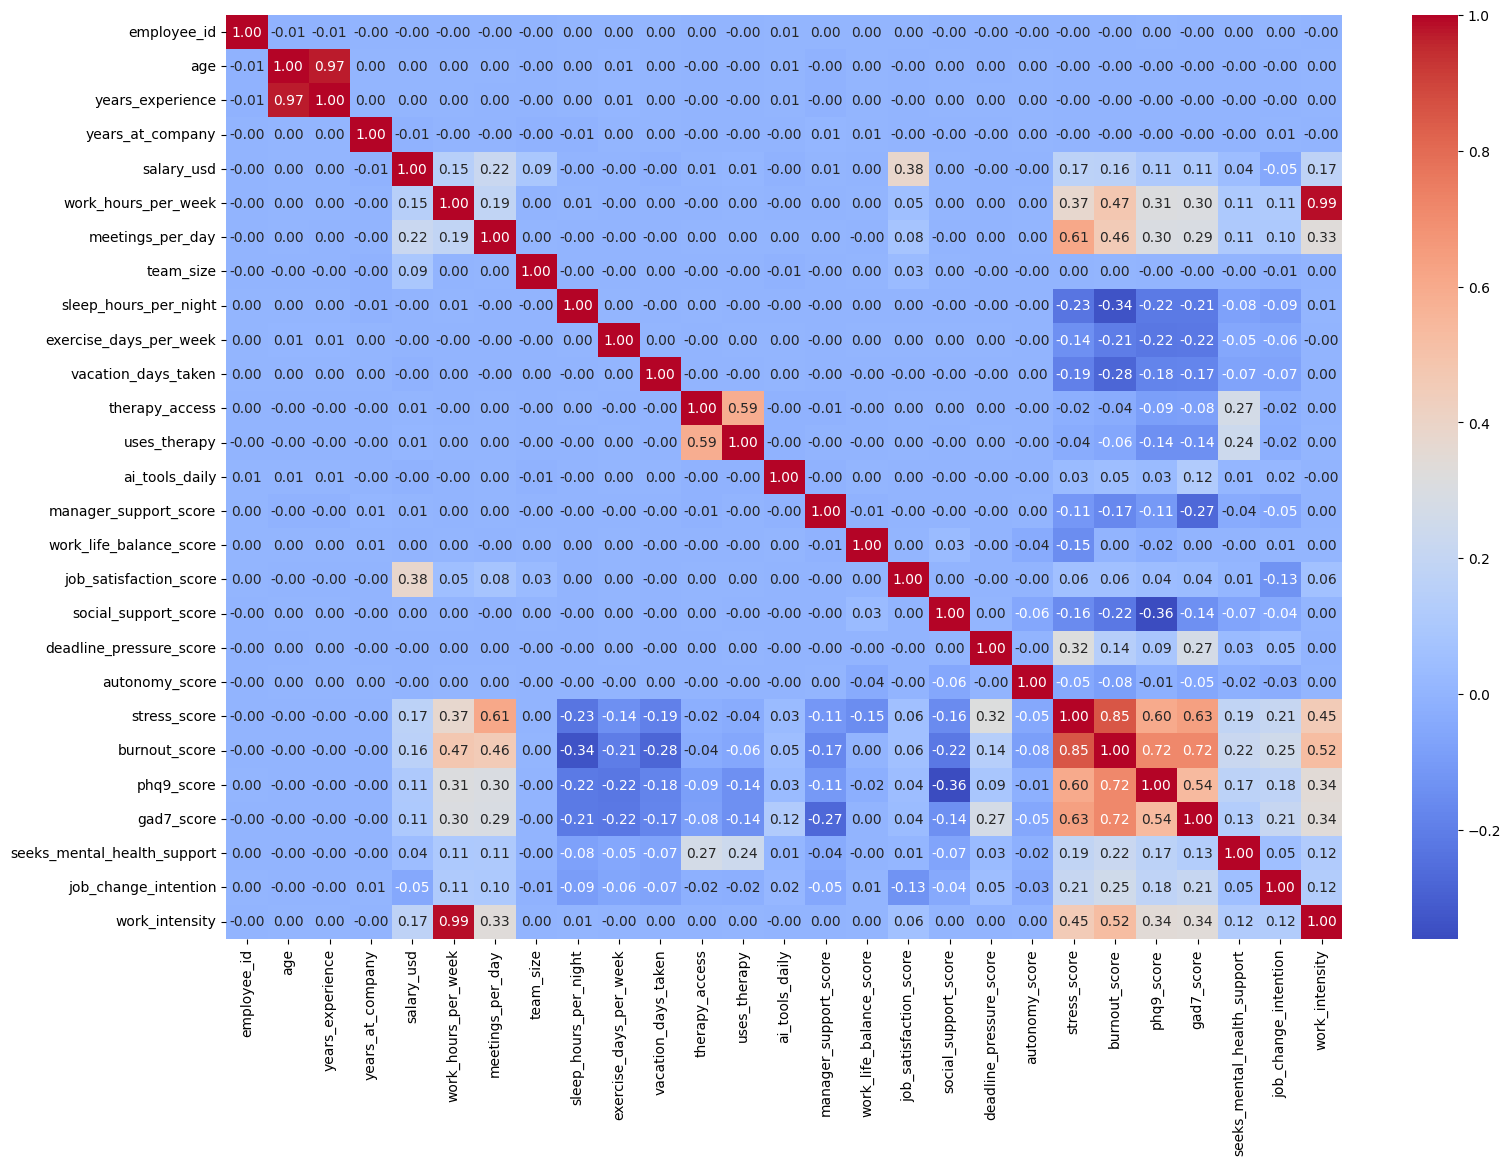

In [40]:
# Correlation Matrix

corr = df.corr(numeric_only=True)

plt.figure(figsize=(18,12))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.show()

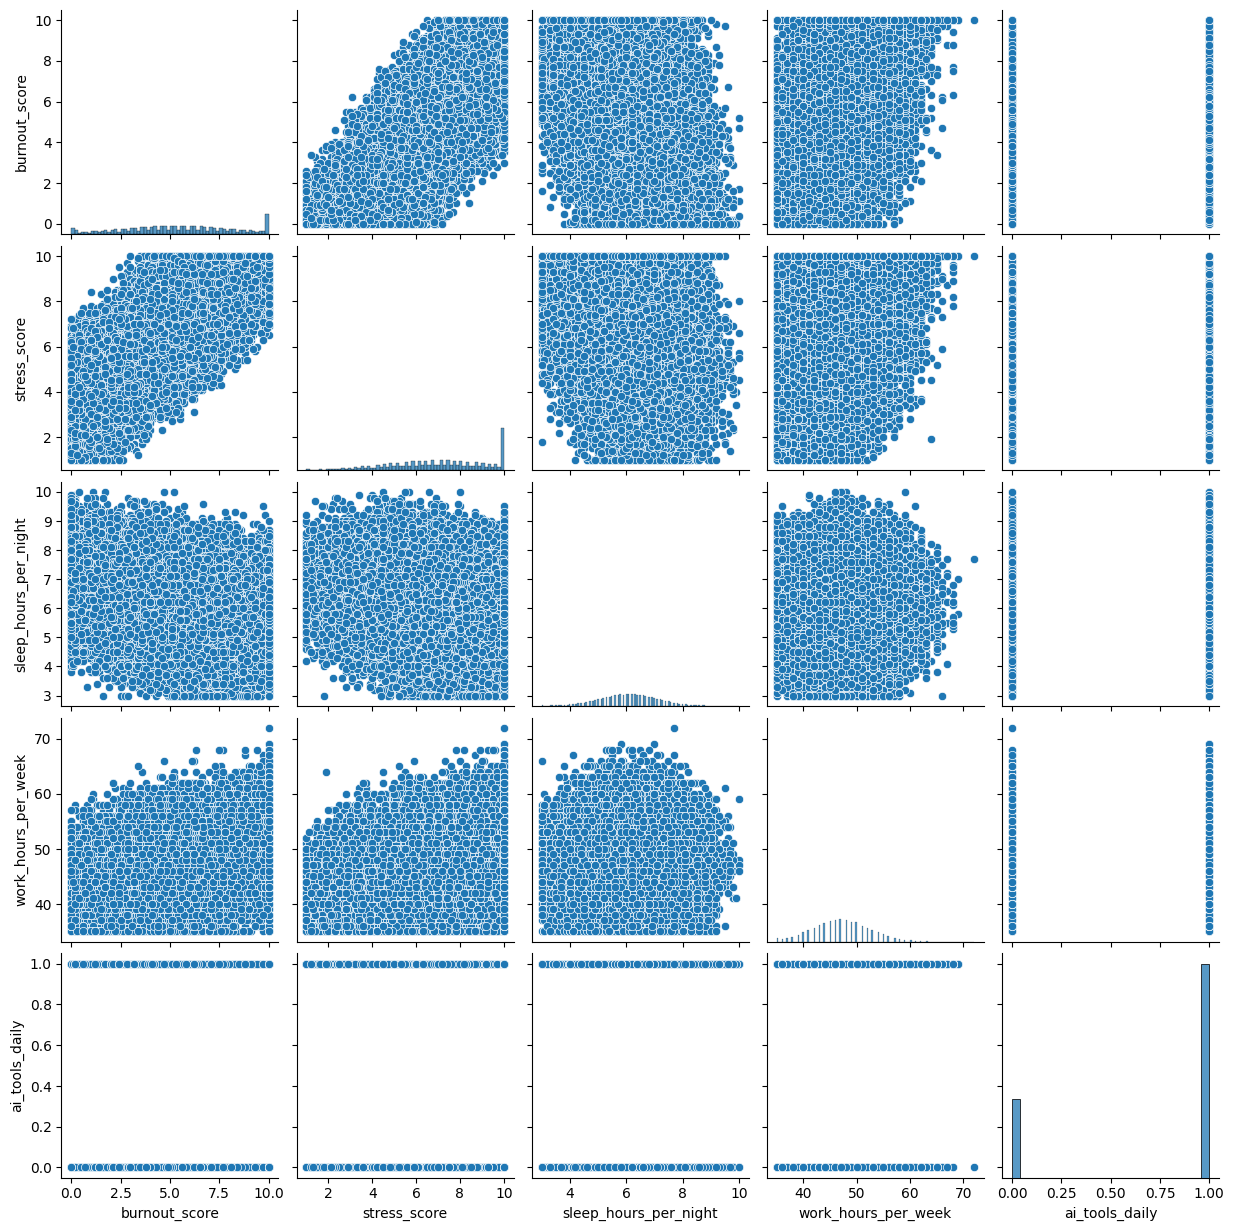

In [41]:
# Pairplot

selected = df[[
    'burnout_score',
    'stress_score',
    'sleep_hours_per_night',
    'work_hours_per_week',
    'ai_tools_daily'
]]

sns.pairplot(selected)

plt.show()

## GROUPED BUSINESS ANALYSIS

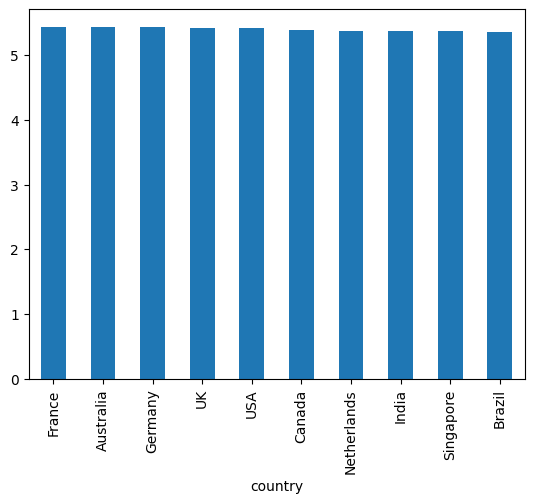

In [43]:
# Average Burnout by Country

country_burnout = df.groupby('country')['burnout_score'] \
                    .mean() \
                    .sort_values(ascending=False)

country_burnout.head(10).plot(kind='bar')
plt.show()

In [44]:
# Burnout by Work Mode

df.groupby('work_mode')['burnout_score'].mean()

work_mode
Hybrid     5.432482
On-site    5.246239
Remote     5.478684
Name: burnout_score, dtype: float64

In [45]:
# Burnout by Job Role

role_burnout = df.groupby('job_role')['burnout_score'] \
                 .mean() \
                 .sort_values(ascending=False)

role_burnout

job_role
Product Manager           5.446679
Backend Developer         5.444785
Frontend Developer        5.422208
ML Engineer               5.415602
QA Engineer               5.405471
Cybersecurity Engineer    5.400100
Data Scientist            5.399900
DevOps Engineer           5.394666
Software Engineer         5.387779
Cloud Engineer            5.380904
Data Analyst              5.370391
Full Stack Developer      5.354727
Name: burnout_score, dtype: float64

In [46]:
# Burnout by Industry

industry_burnout = df.groupby('industry')['burnout_score'] \
                     .mean() \
                     .sort_values(ascending=False)

industry_burnout

industry
AI / ML Startup          5.591486
Fintech                  5.576109
Gaming                   5.542385
Consulting               5.391258
SaaS / Cloud             5.333998
Enterprise Software      5.325763
Social Media / AdTech    5.309614
Healthcare Tech          5.304188
Cybersecurity            5.290684
E-commerce               5.266965
Name: burnout_score, dtype: float64

## RETENTION RISK ANALYSIS

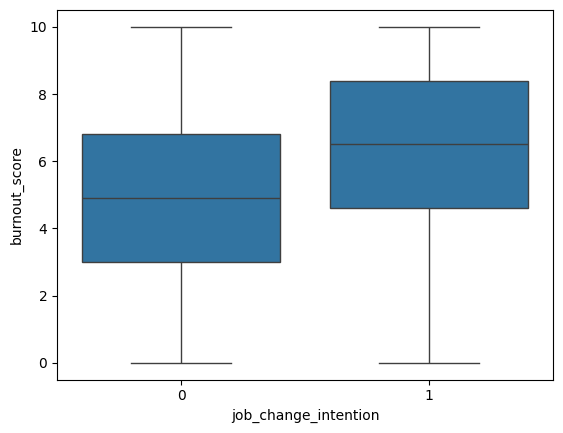

In [47]:
# Burnout vs Job Change Intention

sns.boxplot(
    x='job_change_intention',
    y='burnout_score',
    data=df
)

plt.show()

In [48]:
# Attrition Percentage

attrition_rate = (
    df['job_change_intention'].mean() * 100
)

print(attrition_rate)

32.002


In [49]:
# High Risk Employees

high_risk = df[
    (df['burnout_score'] > 8) &
    (df['job_change_intention'] == 1)
]

high_risk.head()

,employee_id,age,gender,country,job_role,seniority_level,years_experience,years_at_company,company_size,industry,...,burnout_score,phq9_score,phq9_category,gad7_score,gad7_category,burnout_level,seeks_mental_health_support,job_change_intention,burnout_risk,work_intensity
0,1,33,Male,India,Software Engineer,Lead,11,6.4,Small (51-200),Healthcare Tech,...,10.0,19,Moderately Severe (15-19),12,Moderate (10-14),Severe,1,1,High,40.69
2,3,36,Prefer not to say,USA,Software Engineer,Lead,14,5.6,Mid (201-1000),Fintech,...,8.5,8,Mild (5-9),9,Mild (5-9),Severe,0,1,High,33.36
3,4,38,Non-binary,USA,Software Engineer,Lead,14,1.2,Mid (201-1000),SaaS / Cloud,...,10.0,14,Moderate (10-14),11,Moderate (10-14),Severe,0,1,High,39.39
17,18,24,Male,India,ML Engineer,Manager,2,9.3,Enterprise (5000+),E-commerce,...,10.0,13,Moderate (10-14),12,Moderate (10-14),Severe,1,1,High,42.22
25,26,29,Male,USA,Data Scientist,Senior,6,2.1,Enterprise (5000+),E-commerce,...,8.2,6,Mild (5-9),7,Mild (5-9),Severe,1,1,High,37.84


## MENTAL HEALTH ANALYSIS

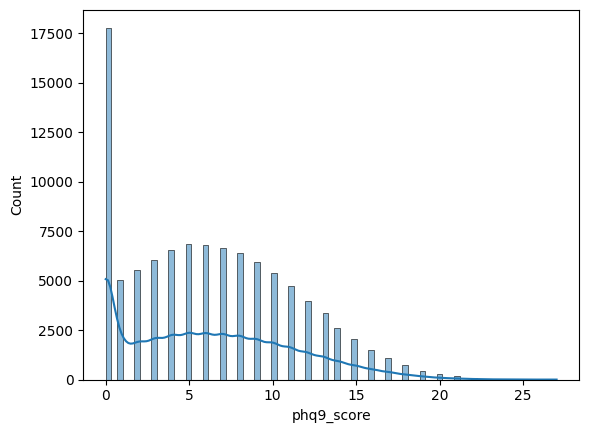

In [50]:
# PHQ9 Distribution

sns.histplot(df['phq9_score'], kde=True)
plt.show()

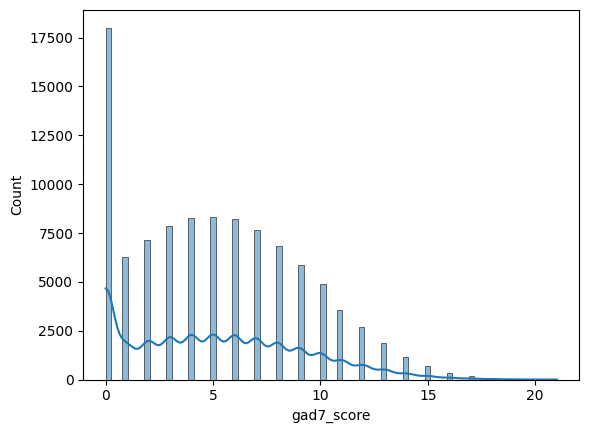

In [51]:
# GAD7 Distribution

sns.histplot(df['gad7_score'], kde=True)
plt.show()

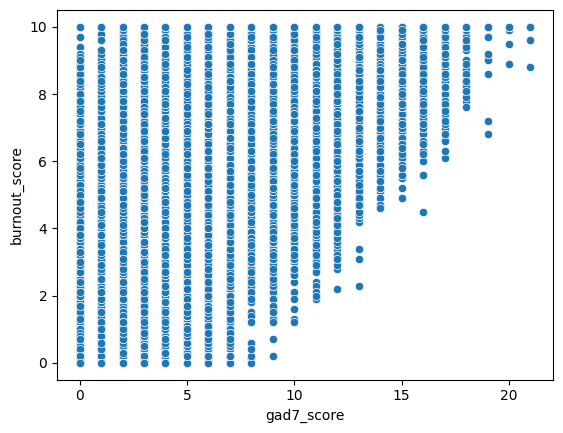

In [52]:
# Anxiety vs Burnout

sns.scatterplot(
    x='gad7_score',
    y='burnout_score',
    data=df
)

plt.show()

## AI IMPACT ANALYSIS

In [11]:
# AI Users vs Non-AI Users

df['ai_user_type'] = df['ai_tools_daily'].map({
    0: 'Non-AI User',
    1: 'AI User'
})


In [12]:

df['ai_user_type'].value_counts()

ai_user_type
AI User        73006
Non-AI User    26994
Name: count, dtype: int64

In [13]:
df['ai_tools_daily'].describe()

count    100000.000000
mean          0.730060
std           0.443931
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: ai_tools_daily, dtype: float64

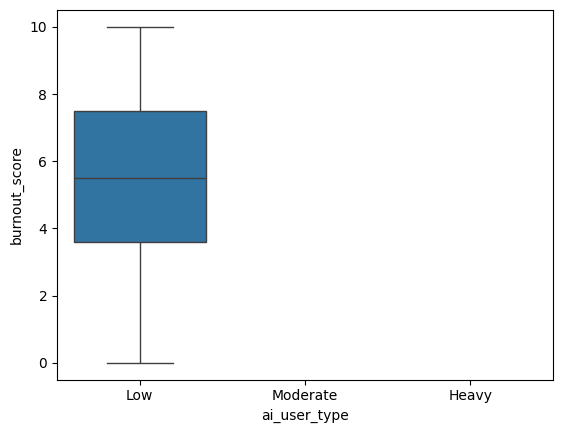

In [54]:
# Burnout Across AI Groups

sns.boxplot(
    x='ai_user_type',
    y='burnout_score',
    data=df
)

plt.show()

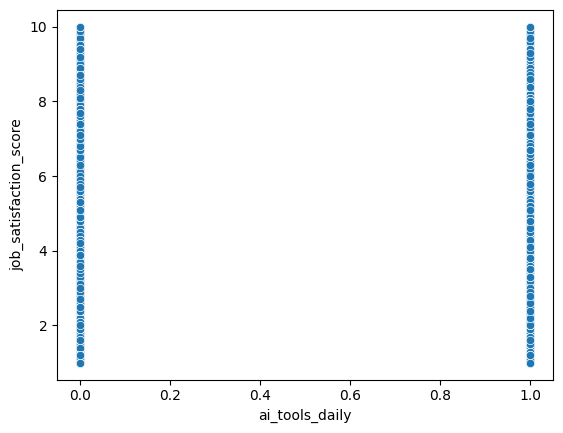

In [55]:
# Productivity vs AI Usage

sns.scatterplot(
    x='ai_tools_daily',
    y='job_satisfaction_score',
    data=df
)

plt.show()

## STATISTICAL ANALYSIS

In [58]:
# Correlation Coefficients

df[['burnout_score',
    'stress_score',
    'sleep_hours_per_night',
    'work_hours_per_week']].corr()

,burnout_score,stress_score,sleep_hours_per_night,work_hours_per_week
burnout_score,1.000000,0.853803,-0.338268,0.474050
stress_score,0.853803,1.000000,-0.231635,0.374966
sleep_hours_per_night,-0.338268,-0.231635,1.000000,0.006383
work_hours_per_week,0.474050,0.374966,0.006383,1.000000


In [59]:
# Hypothesis Testing

#Step 1 — Separate groups

remote = df[df['work_mode'] == 'Remote']['burnout_score']

office = df[df['work_mode'] == 'Onsite']['burnout_score']

In [60]:
# Step 2 — T-Test

from scipy.stats import ttest_ind

ttest_ind(remote, office)

C:\Users\gptvi\AppData\Local\Temp\ipykernel_15800\2140984647.py:5: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ttest_ind(remote, office)


TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

In [15]:
df.to_csv("final_burnout_analysis.csv", index=False)